<div align="center">
  <img src="https://raw.githubusercontent.com/WSU-AI-in-ME/ai-in-me-1/main/img/wsu_logo_horizontal.png" alt="Wayne State University Logo" width="320">
  <h1>Practice 4: Regression for Tool Wear Estimation and Prediction</h1>
</div>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WSU-AI-in-ME/ai-in-me-1/blob/main/practice/week04/practice04_regression_experiments_solution.ipynb)

[Course Repository](https://github.com/WSU-AI-in-ME/ai-in-me-1) · [Practice Index](https://github.com/WSU-AI-in-ME/ai-in-me-1/blob/main/Practice_index.ipynb)

### ME 5995 - AI in Mechanical Engineering I: Fundamentals of Manufacturing Data Science
**Wayne State University · Optional, ungraded self-study · Normally not submitted**  
**Version: Self-check solution**

Try your selected exercises before consulting the solution. Each answer is one
possible approach. [Return to the starter](https://colab.research.google.com/github/WSU-AI-in-ME/ai-in-me-1/blob/main/practice/week04/practice04_regression_experiments.ipynb).

## Student Information

Optional for your personal copy. Double-click this Markdown cell to edit.

**Student name:** Instructor Example  
**WSU AccessID:** example00

## Choose an experiment

| Module | Try changing | Estimated time |
|---|---|---|
| A | Residuals, bias, large errors | 20 minutes |
| B | Sample count, noise, outliers, prediction range | 25–30 minutes |
| C | Polynomial degree, regularization, units | 25–30 minutes |
| D | SVR C, epsilon, gamma, preprocessing | 25–30 minutes |
| E | Cut history, sensors, combined inputs | 25–30 minutes |

Run your chosen module's setup, then any exercise in it. Earlier answers are not
needed. Short route: A1/B1/C1/D1/E4 (45–60 minutes including setups).
Core 20-exercise bank: 120–150 minutes, excluding the optional full-trajectory
view (5–10 minutes) and Ridge extension (10–15 minutes). Module E's estimate
covers E1–E4 only. Estimates are unmeasured; choose rather than complete everything.

Colab: use its installed packages. Locally: install NumPy, pandas, Matplotlib,
scikit-learn and Jupyter in your Python environment. A–D need no files or downloads;
their data and units are illustrative, not measured machining experiments.
E loads the published PHM feature CSV. Change only marked values/expressions;
plotting and comparison code is supplied.

## A — Read errors before judging a model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.rcParams.update({'font.size': 12, 'figure.figsize': (9, 3.6)})
# Synthetic measured/predicted wear in micrometers (µm).
actual = np.array([10., 20., 30., 40.])
prediction = np.array([8., 22., 27., 43.])
# Completed example: a positive residual means underprediction.
print('First residual (µm):', actual[0] - prediction[0])

First residual (µm): 2.0


### A1 — Complete the residual

Complete the subtraction. Which predictions are too low?

In [2]:
residual = actual - prediction
print(residual)

[ 2. -2.  3. -3.]


**One possible response:** Residuals are [2, -2, 3, -3] µm. Predictions 1 and 3 are too low; the sign describes direction, not magnitude.

### A2 — One large error

Predict which metric reacts more; compare large_error=3 and 15.

MAE / RMSE (µm): 5.5 7.7781745930520225


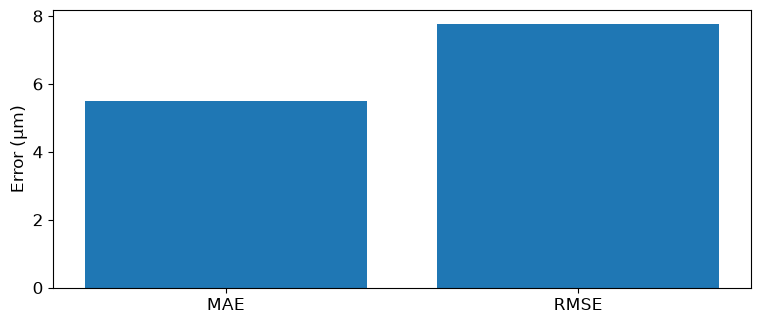

In [3]:
# Change only the last residual: compare 3 and 15 µm.
large_error = 15.0
errors = np.array([2., -2., 3., large_error])
mae = np.mean(np.abs(errors))
rmse = np.sqrt(np.mean(errors ** 2))
print('MAE / RMSE (µm):', mae, rmse)
plt.bar(['MAE', 'RMSE'], [mae, rmse]); plt.ylabel('Error (µm)'); plt.show()

**One possible response:** At 15 µm, MAE is 5.5 µm and RMSE is about 7.78 µm. Squaring gives large errors more influence in RMSE.

### A3 — Bias versus accuracy

Try both signs of bias. Does zero average residual always imply small errors?

Mean residual / MAE (µm): -5.0 5.0


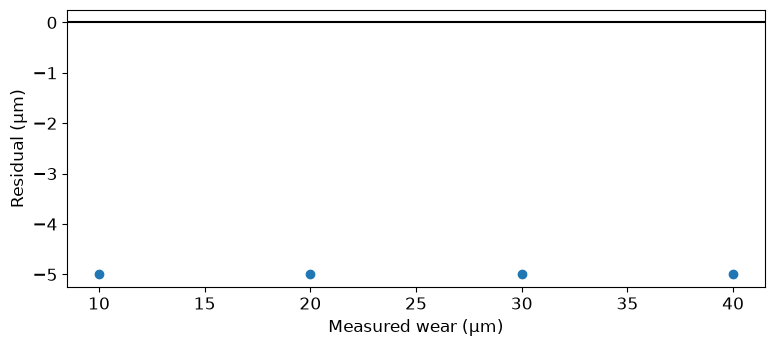

In [4]:
# A constant offset changes bias; it does not add random noise.
bias = 5.0  # Try -5, 0, and 5 µm.
biased_prediction = actual + bias
errors = actual - biased_prediction
print('Mean residual / MAE (µm):', errors.mean(), np.abs(errors).mean())
plt.scatter(actual, errors); plt.axhline(0, color='black');
plt.xlabel('Measured wear (µm)'); plt.ylabel('Residual (µm)'); plt.show()

**One possible response:** A +5 µm prediction bias gives residual -5 µm and MAE 5 µm. Positive and negative errors can cancel in the mean; A1 has mean zero but nonzero MAE.

### A4 — Debug a mean baseline

Correct the baseline source. Why is using validation-target mean misleading?

In [5]:
train_wear = np.array([10., 20., 30.])
valid_wear = np.array([35., 45.])
# DEBUG: choose the mean available before validation targets are observed.
baseline_mean = train_wear.mean()
baseline_pred = np.full(len(valid_wear), baseline_mean)
print('Baseline / validation MAE (µm):', baseline_mean,
      mean_absolute_error(valid_wear, baseline_pred))

Baseline / validation MAE (µm): 20.0 20.0


**One possible response:** The training mean is 20 µm and validation MAE is 20 µm. The validation mean uses information unavailable for predicting a new observation.

## B — Change the data, keep the model

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.rcParams.update({'font.size': 12, 'figure.figsize': (9, 3.6)})
# A fixed synthetic curved wear law; observations include noise.
# The completed model example below is shared only as a reference.
example_x = np.array([0., 1., 2., 3.]).reshape(-1, 1)
example_y = np.array([20., 23., 26., 29.])
example_model = LinearRegression()
example_model.fit(example_x, example_y)
print('Prediction at cut index 4 (µm):', example_model.predict([[4.]]))

Prediction at cut index 4 (µm): [32.]


### B1 — More observations

Compare 6, 12, and 60 training observations. Can more data fix a wrong model shape?

RMSE against noise-free synthetic curve (µm): 18.20427719282595


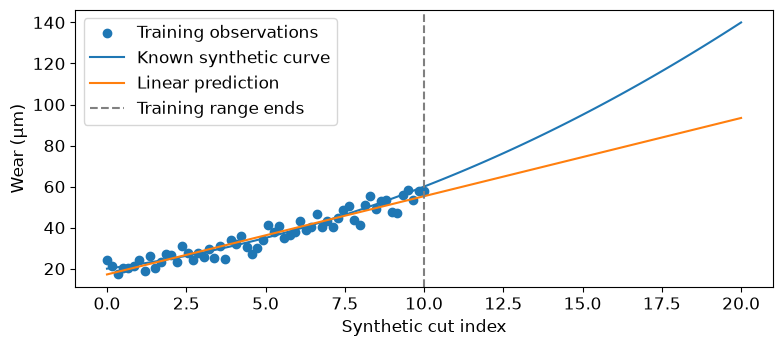

In [7]:
# Editable conditions; each run regenerates its own data.
n_train = 60
noise_sd = 3.0  # Observation noise SD in µm.
outlier = 0.0  # Added to the final training observation, in µm.
end_cut = 20.0  # Prediction range; training always ends at cut 10.
# PROVIDED: the same seed controls reproducibility, not scientific certainty.
rng = np.random.default_rng(24)
train_cut = np.linspace(0, 10, n_train)
train_wear = 20 + 2 * train_cut + .2 * train_cut**2
train_wear = train_wear + rng.normal(0, noise_sd, n_train)
train_wear[-1] += outlier
valid_cut = np.linspace(0, end_cut, 101)
valid_wear = 20 + 2 * valid_cut + .2 * valid_cut**2
model = LinearRegression()
model.fit(train_cut.reshape(-1, 1), train_wear)
pred = model.predict(valid_cut.reshape(-1, 1))
print('RMSE against noise-free synthetic curve (µm):',
      np.sqrt(mean_squared_error(valid_wear, pred)))
plt.scatter(train_cut, train_wear, label='Training observations')
plt.plot(valid_cut, valid_wear, label='Known synthetic curve')
plt.plot(valid_cut, pred, label='Linear prediction')
plt.axvline(10, color='gray', linestyle='--', label='Training range ends')
plt.xlabel('Synthetic cut index'); plt.ylabel('Wear (µm)'); plt.legend(); plt.show()

**One possible response:** More observations may stabilize the fitted line, but a line cannot represent the curved law. One noise realization does not establish a universal trend.

**Self-check comparison:** the supplied table records all requested settings. Other conditions stay at baseline; no new student code is needed.

In [8]:
# PROVIDED SELF-CHECK: reset every condition for each comparison.
check_rows = []
for check_value in [6, 12, 60]:
    check_n = check_value
    check_noise = 3.0
    check_rng = np.random.default_rng(24)
    check_x = np.linspace(0, 10, check_n)
    check_y = 20 + 2*check_x + .2*check_x**2 + check_rng.normal(0, check_noise, check_n)
    check_valid_x = np.linspace(0, 20, 101)
    check_valid_y = 20 + 2*check_valid_x + .2*check_valid_x**2
    check_model = LinearRegression().fit(check_x.reshape(-1, 1), check_y)
    check_pred = check_model.predict(check_valid_x.reshape(-1, 1))
    check_rows.append([check_value, np.sqrt(mean_squared_error(check_valid_y, check_pred))])
display(pd.DataFrame(check_rows, columns=['Training count', 'Reference-curve RMSE (µm)']).round(3))

,Training count,Reference-curve RMSE (µm)
0,6,19.039
1,12,16.960
2,60,18.204


### B2 — More noise

Keep n_train=12; compare noise_sd=0, 3, and 10. Which changes are repeatable?

RMSE against noise-free synthetic curve (µm): 18.22903930087798


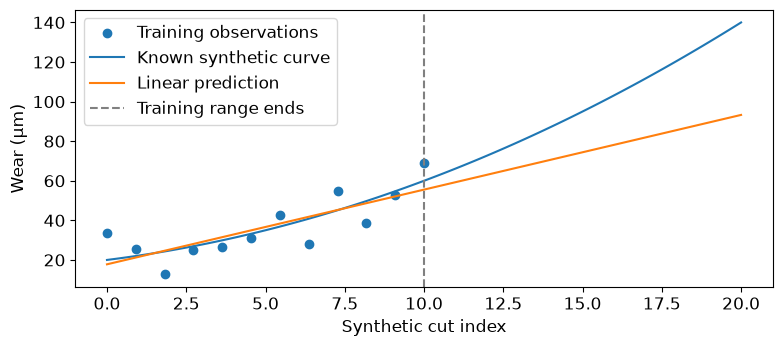

In [9]:
# Editable conditions; each run regenerates its own data.
n_train = 12
noise_sd = 10.0  # Observation noise SD in µm.
outlier = 0.0  # Added to the final training observation, in µm.
end_cut = 20.0  # Prediction range; training always ends at cut 10.
# PROVIDED: the same seed controls reproducibility, not scientific certainty.
rng = np.random.default_rng(24)
train_cut = np.linspace(0, 10, n_train)
train_wear = 20 + 2 * train_cut + .2 * train_cut**2
train_wear = train_wear + rng.normal(0, noise_sd, n_train)
train_wear[-1] += outlier
valid_cut = np.linspace(0, end_cut, 101)
valid_wear = 20 + 2 * valid_cut + .2 * valid_cut**2
model = LinearRegression()
model.fit(train_cut.reshape(-1, 1), train_wear)
pred = model.predict(valid_cut.reshape(-1, 1))
print('RMSE against noise-free synthetic curve (µm):',
      np.sqrt(mean_squared_error(valid_wear, pred)))
plt.scatter(train_cut, train_wear, label='Training observations')
plt.plot(valid_cut, valid_wear, label='Known synthetic curve')
plt.plot(valid_cut, pred, label='Linear prediction')
plt.axvline(10, color='gray', linestyle='--', label='Training range ends')
plt.xlabel('Synthetic cut index'); plt.ylabel('Wear (µm)'); plt.legend(); plt.show()

**One possible response:** Higher noise spreads training observations and can move the line. The clean reference curve stays fixed; repeat with other seeds before making broad claims.

**Self-check comparison:** the supplied table records all requested settings. Other conditions stay at baseline; no new student code is needed.

In [10]:
# PROVIDED SELF-CHECK: reset every condition for each comparison.
check_rows = []
for check_value in [0, 3, 10]:
    check_n = 12
    check_noise = check_value
    check_rng = np.random.default_rng(24)
    check_x = np.linspace(0, 10, check_n)
    check_y = 20 + 2*check_x + .2*check_x**2 + check_rng.normal(0, check_noise, check_n)
    check_valid_x = np.linspace(0, 20, 101)
    check_valid_y = 20 + 2*check_valid_x + .2*check_valid_x**2
    check_model = LinearRegression().fit(check_x.reshape(-1, 1), check_y)
    check_pred = check_model.predict(check_valid_x.reshape(-1, 1))
    check_rows.append([check_value, np.sqrt(mean_squared_error(check_valid_y, check_pred))])
display(pd.DataFrame(check_rows, columns=['Noise SD (µm)', 'Reference-curve RMSE (µm)']).round(3))

,Noise SD (µm),Reference-curve RMSE (µm)
0,0,16.420
1,3,16.960
2,10,18.229


### B3 — One influential observation

Compare outlier=0 and 40. Which end of the line moves most?

RMSE against noise-free synthetic curve (µm): 6.642686674309746


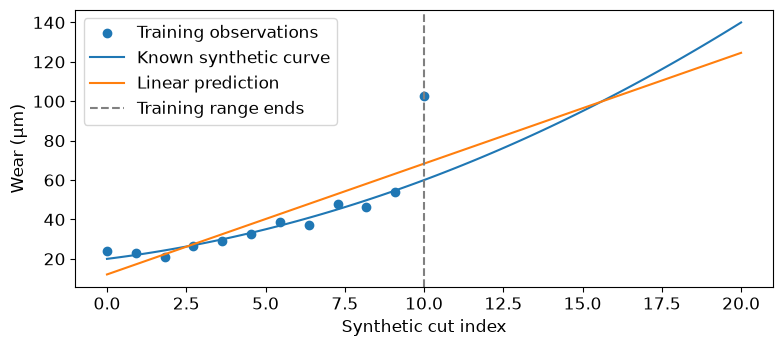

In [11]:
# Editable conditions; each run regenerates its own data.
n_train = 12
noise_sd = 3.0  # Observation noise SD in µm.
outlier = 40.0  # Added to the final training observation, in µm.
end_cut = 20.0  # Prediction range; training always ends at cut 10.
# PROVIDED: the same seed controls reproducibility, not scientific certainty.
rng = np.random.default_rng(24)
train_cut = np.linspace(0, 10, n_train)
train_wear = 20 + 2 * train_cut + .2 * train_cut**2
train_wear = train_wear + rng.normal(0, noise_sd, n_train)
train_wear[-1] += outlier
valid_cut = np.linspace(0, end_cut, 101)
valid_wear = 20 + 2 * valid_cut + .2 * valid_cut**2
model = LinearRegression()
model.fit(train_cut.reshape(-1, 1), train_wear)
pred = model.predict(valid_cut.reshape(-1, 1))
print('RMSE against noise-free synthetic curve (µm):',
      np.sqrt(mean_squared_error(valid_wear, pred)))
plt.scatter(train_cut, train_wear, label='Training observations')
plt.plot(valid_cut, valid_wear, label='Known synthetic curve')
plt.plot(valid_cut, pred, label='Linear prediction')
plt.axvline(10, color='gray', linestyle='--', label='Training range ends')
plt.xlabel('Synthetic cut index'); plt.ylabel('Wear (µm)'); plt.legend(); plt.show()

**One possible response:** A high observation at the largest training cut can increase the slope. Least squares is sensitive to large residuals; do not delete real data merely to improve a score.

### B4 — Predict beyond training

Compare end_cut=10 and 20. Why are the two RMSE values not an apples-to-apples ranking?

RMSE against noise-free synthetic curve (µm): 1.5433086320800937


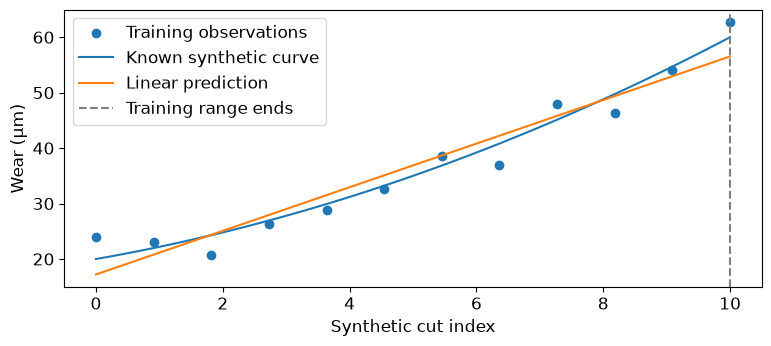

In [12]:
# Editable conditions; each run regenerates its own data.
n_train = 12
noise_sd = 3.0  # Observation noise SD in µm.
outlier = 0.0  # Added to the final training observation, in µm.
end_cut = 10.0  # Prediction range; training always ends at cut 10.
# PROVIDED: the same seed controls reproducibility, not scientific certainty.
rng = np.random.default_rng(24)
train_cut = np.linspace(0, 10, n_train)
train_wear = 20 + 2 * train_cut + .2 * train_cut**2
train_wear = train_wear + rng.normal(0, noise_sd, n_train)
train_wear[-1] += outlier
valid_cut = np.linspace(0, end_cut, 101)
valid_wear = 20 + 2 * valid_cut + .2 * valid_cut**2
model = LinearRegression()
model.fit(train_cut.reshape(-1, 1), train_wear)
pred = model.predict(valid_cut.reshape(-1, 1))
print('RMSE against noise-free synthetic curve (µm):',
      np.sqrt(mean_squared_error(valid_wear, pred)))
plt.scatter(train_cut, train_wear, label='Training observations')
plt.plot(valid_cut, valid_wear, label='Known synthetic curve')
plt.plot(valid_cut, pred, label='Linear prediction')
plt.axvline(10, color='gray', linestyle='--', label='Training range ends')
plt.xlabel('Synthetic cut index'); plt.ylabel('Wear (µm)'); plt.legend(); plt.show()

**One possible response:** The evaluated input range changes. The fit is identical but predicting past cut 10 extrapolates a linear trend beyond the observed range; compare curves as well as scores.

## C — Complexity, regularization, and units

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.rcParams.update({'font.size': 12, 'figure.figsize': (9, 3.6)})
# Synthetic vibration amplitude (g) and wear (µm); no causal claim.
rng = np.random.default_rng(8)
x_train = np.linspace(0, 2, 18).reshape(-1, 1)
y_train = 30 + 12*x_train[:, 0] + 15*x_train[:, 0]**2 + rng.normal(0, 6, 18)
x_valid = np.linspace(.05, 1.95, 61).reshape(-1, 1)
y_valid = 30 + 12*x_valid[:, 0] + 15*x_valid[:, 0]**2 + rng.normal(0, 6, 61)
# A pipeline applies transformations in order and fits them only on training data.
example = make_pipeline(PolynomialFeatures(2, include_bias=False),
                        StandardScaler(), Ridge(alpha=1.0))
example.fit(x_train, y_train)
print('Example validation RMSE:', np.sqrt(mean_squared_error(y_valid, example.predict(x_valid))))

Example validation RMSE: 6.664423639380204


### C1 — Polynomial degree

Predict whether degree=8 must beat degree=2 on validation; run 1, 2, 8.

Train / validation RMSE (µm): 3.5804711581743263 7.816158896459211


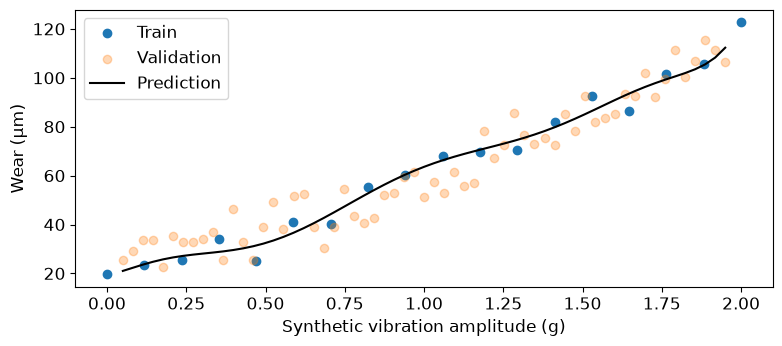

In [14]:
degree = 8  # Compare 1, 2, and 8.
alpha = 0.0  # Zero uses ordinary least squares; compare 0.1, 1, and 100 for Ridge.
# PROVIDED: expand powers, scale each expanded feature, then fit the estimator.
estimator = LinearRegression() if alpha == 0 else Ridge(alpha=alpha)
model = make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), estimator)
model.fit(x_train, y_train)
train_pred = model.predict(x_train)
pred = model.predict(x_valid)
print('Train / validation RMSE (µm):', np.sqrt(mean_squared_error(y_train, train_pred)),
      np.sqrt(mean_squared_error(y_valid, pred)))
plt.scatter(x_train[:, 0], y_train, label='Train')
plt.scatter(x_valid[:, 0], y_valid, alpha=.3, label='Validation')
plt.plot(x_valid[:, 0], pred, color='black', label='Prediction')
plt.xlabel('Synthetic vibration amplitude (g)'); plt.ylabel('Wear (µm)'); plt.legend(); plt.show()

**One possible response:** Higher degree permits more curvature and may reduce training error, but validation can worsen. The synthetic generating mean is quadratic; noisy observations need not lie on it.

### C2 — Shrink a flexible model

Hold degree=8 and compare alpha=0.1, 1, 100. Inspect both RMSE values.

Train / validation RMSE (µm): 16.955437158141244 14.493797247481337


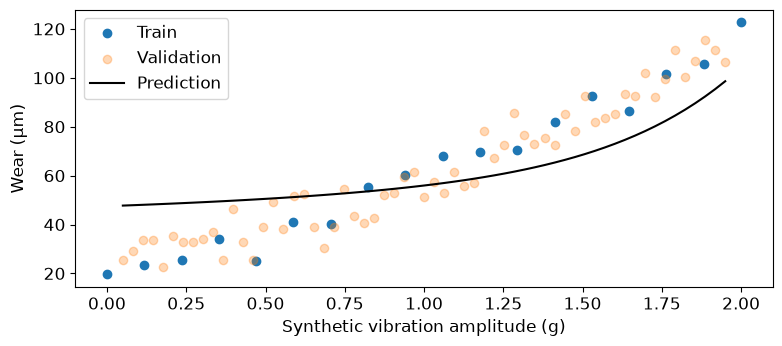

In [15]:
degree = 8  # Compare 1, 2, and 8.
alpha = 100.0  # Zero uses ordinary least squares; compare 0.1, 1, and 100 for Ridge.
# PROVIDED: expand powers, scale each expanded feature, then fit the estimator.
estimator = LinearRegression() if alpha == 0 else Ridge(alpha=alpha)
model = make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), estimator)
model.fit(x_train, y_train)
train_pred = model.predict(x_train)
pred = model.predict(x_valid)
print('Train / validation RMSE (µm):', np.sqrt(mean_squared_error(y_train, train_pred)),
      np.sqrt(mean_squared_error(y_valid, pred)))
plt.scatter(x_train[:, 0], y_train, label='Train')
plt.scatter(x_valid[:, 0], y_valid, alpha=.3, label='Validation')
plt.plot(x_valid[:, 0], pred, color='black', label='Prediction')
plt.xlabel('Synthetic vibration amplitude (g)'); plt.ylabel('Wear (µm)'); plt.legend(); plt.show()

**One possible response:** Regularization limits coefficient size in the scaled polynomial basis. Stronger shrinkage can suppress unstable curvature but also underfit; choose from validation evidence, not the largest alpha.

### C3 — Change units

Compare all four combinations. Does changing g to milli-g add information?

Validation RMSE (µm): 10.69373480337195


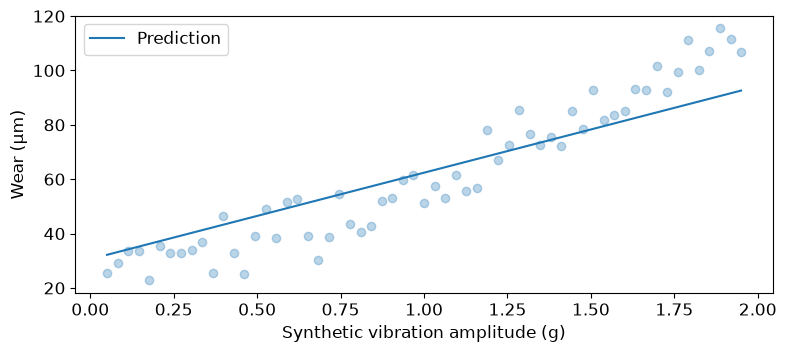

In [16]:
unit_factor = 1000.0  # Compare g (1) with milli-g (1000).
scale_inputs = True  # Repeat both unit choices with True.
train_units = x_train * unit_factor
valid_units = x_valid * unit_factor
# Same physical observations and alpha; only units/preprocessing change.
model = make_pipeline(StandardScaler(), Ridge(alpha=10)) if scale_inputs else Ridge(alpha=10)
model.fit(train_units, y_train)
pred = model.predict(valid_units)
print('Validation RMSE (µm):', np.sqrt(mean_squared_error(y_valid, pred)))
plt.plot(x_valid[:, 0], pred, label='Prediction'); plt.scatter(x_valid[:, 0], y_valid, alpha=.3)
plt.xlabel('Synthetic vibration amplitude (g)'); plt.ylabel('Wear (µm)'); plt.legend(); plt.show()

**One possible response:** Unit conversion adds no information. Without scaling, the same alpha penalizes differently sized coefficients differently. Training-only standardization makes these two positive unit rescalings equivalent up to roundoff.

**Self-check comparison:** all four unit/scaling combinations, with alpha fixed at 10.

In [17]:
# PROVIDED SELF-CHECK: only units and input scaling change.
unit_rows = []
for check_factor in [1.0, 1000.0]:
    for check_scale in [False, True]:
        check_model = make_pipeline(StandardScaler(), Ridge(alpha=10)) if check_scale else Ridge(alpha=10)
        check_model.fit(x_train * check_factor, y_train)
        check_pred = check_model.predict(x_valid * check_factor)
        unit_rows.append([check_factor, check_scale, np.sqrt(mean_squared_error(y_valid, check_pred))])
unit_scores = pd.DataFrame(unit_rows, columns=['Unit multiplier', 'Standardize', 'Validation RMSE (µm)'])
display(unit_scores.round(3))

,Unit multiplier,Standardize,Validation RMSE (µm)
0,1.0,False,16.030
1,1.0,True,10.694
2,1000.0,False,8.128
3,1000.0,True,10.694


### C4 — Debug model selection

Fix the selection column. Can this validation result also be reported as an untouched final test?

In [18]:
# PROVIDED: candidate models use exactly the same observations.
rows = []
for degree in [1, 2, 8]:
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), LinearRegression())
    model.fit(x_train, y_train)
    rows.append([degree, np.sqrt(mean_squared_error(y_train, model.predict(x_train))),
                 np.sqrt(mean_squared_error(y_valid, model.predict(x_valid)))])
scores = pd.DataFrame(rows, columns=['degree', 'train_RMSE_um', 'valid_RMSE_um'])
display(scores)
# DEBUG: select the column that measures performance beyond the fitting observations.
selection_column = 'valid_RMSE_um'
print('Selected degree:', scores.loc[scores[selection_column].idxmin(), 'degree'])

,degree,train_RMSE_um,valid_RMSE_um
0,1,5.359023,8.128406
1,2,4.566644,7.064885
2,8,3.580471,7.816159


Selected degree: 2


**One possible response:** Degree 2 has validation RMSE 7.06 µm, versus 8.13 for degree 1 and 7.82 for degree 8. Degree 8 has the smallest training error, but does not win on validation. These repeatedly inspected observations are not an untouched final test.

## D — SVR settings and preprocessing

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.rcParams.update({'font.size': 12, 'figure.figsize': (9, 3.6)})
# Synthetic curved sensor-to-wear relationship; units are illustrative.
rng = np.random.default_rng(12)
x_train = np.linspace(0, 3, 30).reshape(-1, 1)
y_train = 40 + 20*np.sin(x_train[:, 0]) + rng.normal(0, 2, 30)
x_valid = np.linspace(.03, 2.97, 80).reshape(-1, 1)
y_valid = 40 + 20*np.sin(x_valid[:, 0]) + rng.normal(0, 2, 80)
scaler = StandardScaler()
z_train = scaler.fit_transform(x_train)  # Learn mean/SD from training only.
z_valid = scaler.transform(x_valid)  # Reuse the same transformation.
example = SVR(C=10, epsilon=1, gamma='scale')
example.fit(z_train, y_train)
print('First example prediction (µm):', example.predict(z_valid[:1]))

First example prediction (µm): [44.27710172]


### D1 — C

Compare C=0.1, 10, 1000; keep epsilon and gamma fixed.

Validation RMSE (µm) / support vectors: 2.058794559571833 16


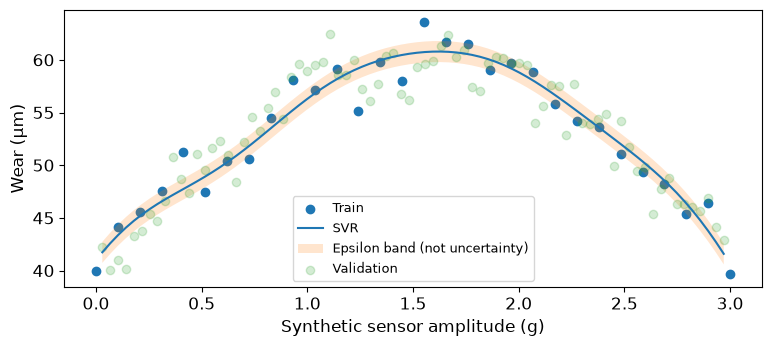

In [20]:
C = 1000.0  # Larger C penalizes deviations outside the epsilon band more.
epsilon = 1.0  # Tolerance in µm because y is not scaled.
gamma = 1.0  # Kernel locality in standardized input coordinates.
model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
model.fit(z_train, y_train)
pred = model.predict(z_valid)
print('Validation RMSE (µm) / support vectors:',
      np.sqrt(mean_squared_error(y_valid, pred)), len(model.support_))
plt.scatter(x_train[:, 0], y_train, label='Train')
plt.plot(x_valid[:, 0], pred, label='SVR')
plt.fill_between(x_valid[:, 0], pred-epsilon, pred+epsilon, alpha=.2, label='Epsilon band (not uncertainty)')
plt.scatter(x_valid[:, 0], y_valid, alpha=.2, label='Validation')
plt.xlabel('Synthetic sensor amplitude (g)'); plt.ylabel('Wear (µm)'); plt.legend(fontsize=9); plt.show()

**One possible response:** C controls the penalty for deviations beyond epsilon; it is not polynomial degree. Larger C need not give the lowest validation error.

**Self-check comparison:** vary C only; other settings remain C=10, epsilon=1, gamma=1.

In [21]:
# PROVIDED SELF-CHECK: use the same training-only scaled inputs for each setting.
check_rows = []
for check_value in [0.1, 10, 1000]:
    check_model = SVR(C=check_value,
                      epsilon=1,
                      gamma=1)
    check_model.fit(z_train, y_train)
    check_pred = check_model.predict(z_valid)
    check_rows.append([check_value, np.sqrt(mean_squared_error(y_valid, check_pred)), len(check_model.support_)])
display(pd.DataFrame(check_rows, columns=['C', 'Validation RMSE (µm)', 'Support vectors']).round(3))

,C,Validation RMSE (µm),Support vectors
0,0.1,5.688,28
1,10.0,2.162,16
2,1000.0,2.059,16


### D2 — Epsilon

Compare epsilon=0.1, 1, 8. What happens to the band and support-vector count?

Validation RMSE (µm) / support vectors: 4.148911816671346 3


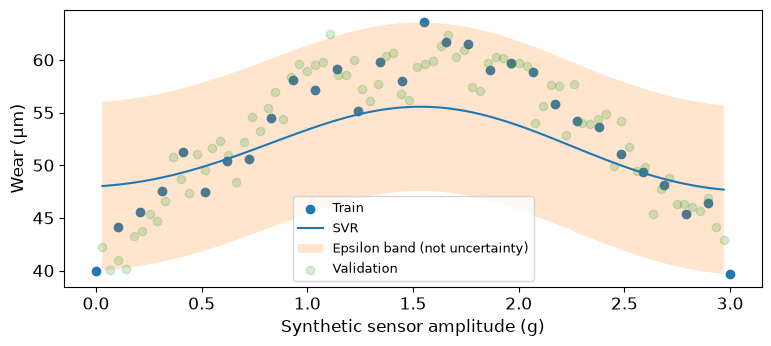

In [22]:
C = 10.0  # Larger C penalizes deviations outside the epsilon band more.
epsilon = 8.0  # Tolerance in µm because y is not scaled.
gamma = 1.0  # Kernel locality in standardized input coordinates.
model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
model.fit(z_train, y_train)
pred = model.predict(z_valid)
print('Validation RMSE (µm) / support vectors:',
      np.sqrt(mean_squared_error(y_valid, pred)), len(model.support_))
plt.scatter(x_train[:, 0], y_train, label='Train')
plt.plot(x_valid[:, 0], pred, label='SVR')
plt.fill_between(x_valid[:, 0], pred-epsilon, pred+epsilon, alpha=.2, label='Epsilon band (not uncertainty)')
plt.scatter(x_valid[:, 0], y_valid, alpha=.2, label='Validation')
plt.xlabel('Synthetic sensor amplitude (g)'); plt.ylabel('Wear (µm)'); plt.legend(fontsize=9); plt.show()

**One possible response:** Epsilon is a tolerance in target units. A wider band often needs fewer support vectors, but inspect the actual count. It is not a confidence or prediction interval.

**Self-check comparison:** vary epsilon only; other settings remain C=10, epsilon=1, gamma=1.

In [23]:
# PROVIDED SELF-CHECK: use the same training-only scaled inputs for each setting.
check_rows = []
for check_value in [0.1, 1, 8]:
    check_model = SVR(C=10,
                      epsilon=check_value,
                      gamma=1)
    check_model.fit(z_train, y_train)
    check_pred = check_model.predict(z_valid)
    check_rows.append([check_value, np.sqrt(mean_squared_error(y_valid, check_pred)), len(check_model.support_)])
display(pd.DataFrame(check_rows, columns=['epsilon', 'Validation RMSE (µm)', 'Support vectors']).round(3))

,epsilon,Validation RMSE (µm),Support vectors
0,0.1,2.162,30
1,1.0,2.162,16
2,8.0,4.149,3


### D3 — Gamma

Compare gamma=0.01, 1, 100. Look for overly flat or highly local behavior.

Validation RMSE (µm) / support vectors: 2.29707068970447 26


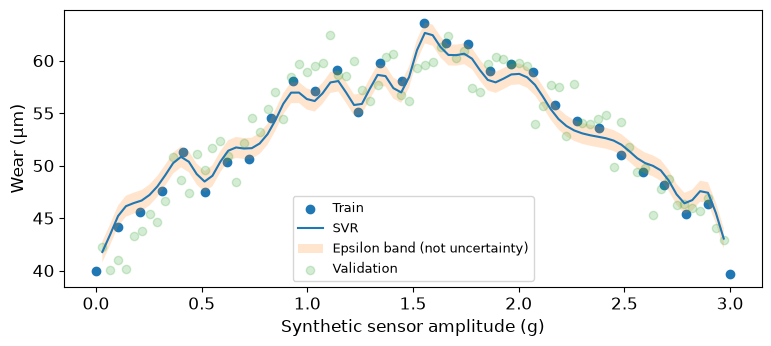

In [24]:
C = 10.0  # Larger C penalizes deviations outside the epsilon band more.
epsilon = 1.0  # Tolerance in µm because y is not scaled.
gamma = 100.0  # Kernel locality in standardized input coordinates.
model = SVR(kernel='rbf', C=C, epsilon=epsilon, gamma=gamma)
model.fit(z_train, y_train)
pred = model.predict(z_valid)
print('Validation RMSE (µm) / support vectors:',
      np.sqrt(mean_squared_error(y_valid, pred)), len(model.support_))
plt.scatter(x_train[:, 0], y_train, label='Train')
plt.plot(x_valid[:, 0], pred, label='SVR')
plt.fill_between(x_valid[:, 0], pred-epsilon, pred+epsilon, alpha=.2, label='Epsilon band (not uncertainty)')
plt.scatter(x_valid[:, 0], y_valid, alpha=.2, label='Validation')
plt.xlabel('Synthetic sensor amplitude (g)'); plt.ylabel('Wear (µm)'); plt.legend(fontsize=9); plt.show()

**One possible response:** Large gamma makes each support vector influential over a narrower input region. High locality can follow noise and worsen validation; the input scale matters.

**Self-check comparison:** vary gamma only; other settings remain C=10, epsilon=1, gamma=1.

In [25]:
# PROVIDED SELF-CHECK: use the same training-only scaled inputs for each setting.
check_rows = []
for check_value in [0.01, 1, 100]:
    check_model = SVR(C=10,
                      epsilon=1,
                      gamma=check_value)
    check_model.fit(z_train, y_train)
    check_pred = check_model.predict(z_valid)
    check_rows.append([check_value, np.sqrt(mean_squared_error(y_valid, check_pred)), len(check_model.support_)])
display(pd.DataFrame(check_rows, columns=['gamma', 'Validation RMSE (µm)', 'Support vectors']).round(3))

,gamma,Validation RMSE (µm),Support vectors
0,0.01,6.026,28
1,1.00,2.162,16
2,100.00,2.297,26


### D4 — Debug validation scaling

Replace one method call. A small score difference does not make an incorrect workflow acceptable.

In [26]:
# Start a fresh scaler so this exercise never depends on an earlier action.
scaler_check = StandardScaler()
train_scaled = scaler_check.fit_transform(x_train)
# DEBUG: do not learn a new origin/scale from the validation observations.
valid_scaled = scaler_check.transform(x_valid)
model = SVR(C=10, epsilon=1, gamma=1)
model.fit(train_scaled, y_train)
pred = model.predict(valid_scaled)
print('Scaler mean / training mean:', scaler_check.mean_, x_train.mean(axis=0))
# Both grids have mean 1.5: the mean alone cannot reveal the incorrect refit.
# StandardScaler uses population SD (ddof=0), matching NumPy's default below.
print('Scaler SD / training SD:', scaler_check.scale_, x_train.std(axis=0))
print('Scaler SD still matches training:', np.allclose(scaler_check.scale_, x_train.std(axis=0)))
print('Validation RMSE (µm):', np.sqrt(mean_squared_error(y_valid, pred)))

Scaler mean / training mean: [1.5] [1.5]
Scaler SD / training SD: [0.89539049] [0.89539049]
Scaler SD still matches training: True
Validation RMSE (µm): 2.1624972566323084


**One possible response:** Use transform for validation. Both grids have mean 1.5, so matching means cannot prove correctness. After the fix, the displayed scaler SD matches the training SD; before the fix it does not. Refitting changes coordinates using validation inputs, even when scores barely change.

## E — What information does the model receive?

**A:** cut number (usage history). **B:** 11 sensor summaries. **C:** both.
Same Linear Regression family and same observations for all three.

PHM Society 2010 Data Challenge, course-derived per-cut summaries; target is the
mean of three flute-wear measurements in µm. Sensor inputs: six force mean/SD,
three vibration SD, and two AE-RMS mean/SD values. Recorded channels were sampled
at 50 kHz; this exercise uses summaries, not raw signals.
[Source](https://phmsociety.org/phm_competition/2010-phm-society-conference-data-challenge/) ·
[Course provenance and redistribution notes](https://raw.githubusercontent.com/WSU-AI-in-ME/ai-in-me-1/main/data/phm2010/features/README.md) ·
[Column definitions and units](https://raw.githubusercontent.com/WSU-AI-in-ME/ai-in-me-1/main/data/phm2010/features/DATA_DICTIONARY.md).

Train: cuts 1–157 of c1/c4/c6. Validation: 158–220. Later cuts 221–315 are
excluded from fitting and selection; the final optional plot reveals them only
after your validation-based comparison is complete.
These are later cuts of observed cutters, not new-cutter evaluation.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.rcParams.update({'font.size': 12, 'figure.figsize': (9, 3.6)})
from pathlib import Path
# Prefer a local course checkout; otherwise read the published feature CSV.
data_path = Path('data/phm2010/features/phm2010_features.csv')
if not data_path.exists():
    data_path = Path('phm2010_features.csv')
if not data_path.exists():
    data_path = 'https://raw.githubusercontent.com/WSU-AI-in-ME/ai-in-me-1/main/data/phm2010/features/phm2010_features.csv'
data = pd.read_csv(data_path)
data = data[data['cutter_id'].isin(['c1', 'c4', 'c6'])].sort_values(['cutter_id', 'cut_number'])
sensor_columns = ['force_x_mean', 'force_x_sd', 'force_y_mean', 'force_y_sd', 'force_z_mean', 'force_z_sd', 'vibration_x_sd', 'vibration_y_sd', 'vibration_z_sd', 'ae_rms_mean', 'ae_rms_sd']
train = data[data['cut_number'] <= 157].copy()
valid = data[(data['cut_number'] >= 158) & (data['cut_number'] <= 220)].copy()
y_train = train['wear_mean_um']
y_valid = valid['wear_mean_um']
print('Training / validation rows:', len(train), len(valid))
# Completed tiny example: double brackets retain a two-dimensional input table.
print('Cut-only input shape:', train[['cut_number']].shape)

Training / validation rows: 471 189
Cut-only input shape: (471, 1)


### E1 — Model A: usage history

Run cut-only A. What information would deployment require? Can A predict different wear for two cutters at the same cut number?

Input count / validation RMSE (µm): 1 17.223458490438386


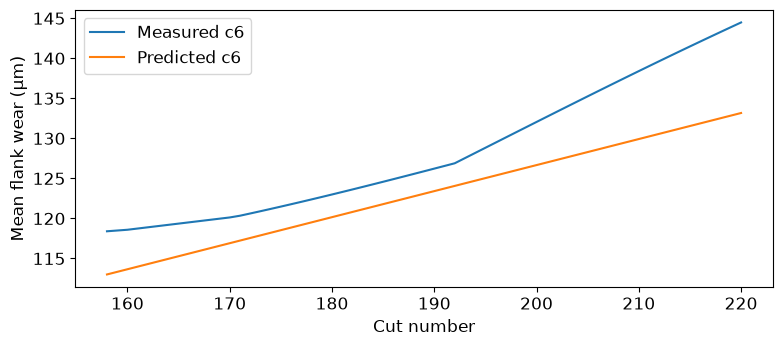

In [28]:
input_columns = ['cut_number']  # Editable input definition.
# PROVIDED: all other choices are identical across A/B/C.
model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(train[input_columns], y_train)
pred = model.predict(valid[input_columns])
print('Input count / validation RMSE (µm):', len(input_columns), np.sqrt(mean_squared_error(y_valid, pred)))
# Plot only c6 validation cuts for a compact view; the score above pools all cutters.
c6 = valid['cutter_id'].to_numpy() == 'c6'
plt.plot(valid.loc[c6, 'cut_number'], y_valid[c6], label='Measured c6')
plt.plot(valid.loc[c6, 'cut_number'], pred[c6], label='Predicted c6')
plt.xlabel('Cut number'); plt.ylabel('Mean flank wear (µm)'); plt.legend(); plt.show()

**One possible response:** A requires the cumulative cut count, not sensor measurements. With one shared line it gives the same prediction at the same cut count for all cutters; different wear trajectories are not represented.

### E2 — Model B: sensors

Replace input_columns with sensor_columns. Compare with A using the same split.

Input count / validation RMSE (µm): 11 20.483841474615303


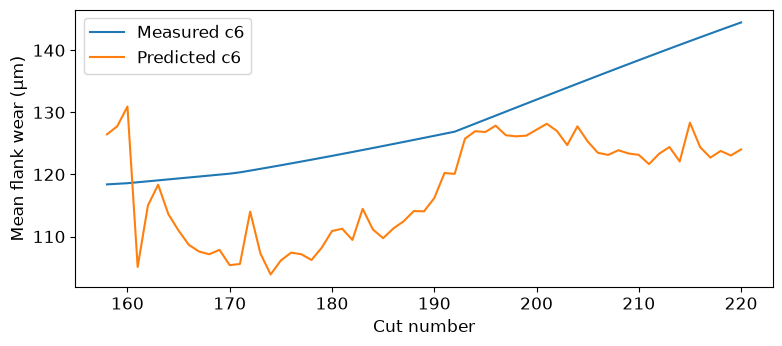

In [29]:
input_columns = sensor_columns  # Editable input definition.
# PROVIDED: all other choices are identical across A/B/C.
model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(train[input_columns], y_train)
pred = model.predict(valid[input_columns])
print('Input count / validation RMSE (µm):', len(input_columns), np.sqrt(mean_squared_error(y_valid, pred)))
# Plot only c6 validation cuts for a compact view; the score above pools all cutters.
c6 = valid['cutter_id'].to_numpy() == 'c6'
plt.plot(valid.loc[c6, 'cut_number'], y_valid[c6], label='Measured c6')
plt.plot(valid.loc[c6, 'cut_number'], pred[c6], label='Predicted c6')
plt.xlabel('Cut number'); plt.ylabel('Mean flank wear (µm)'); plt.legend(); plt.show()

**One possible response:** B needs the same sensor summaries from a completed cut and can distinguish cuts with different measurements. A difference in error concerns these inputs and this split; it is not proof that sensors cause wear.

### E3 — Model C: combined

Use ['cut_number'] + sensor_columns. Does adding a feature guarantee better validation?

Input count / validation RMSE (µm): 12 8.685340030024008


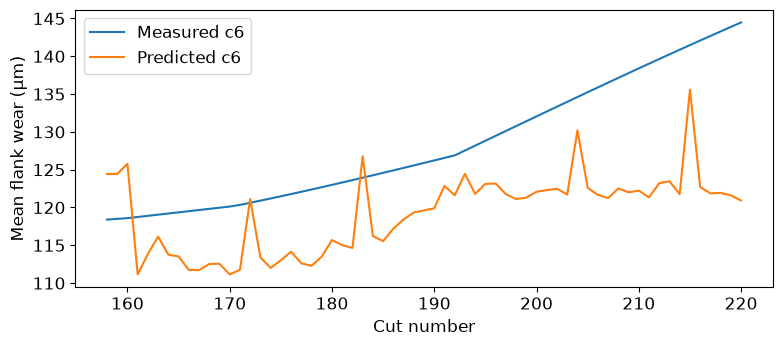

In [30]:
input_columns = ['cut_number'] + sensor_columns  # Editable input definition.
# PROVIDED: all other choices are identical across A/B/C.
model = make_pipeline(StandardScaler(), LinearRegression())
model.fit(train[input_columns], y_train)
pred = model.predict(valid[input_columns])
print('Input count / validation RMSE (µm):', len(input_columns), np.sqrt(mean_squared_error(y_valid, pred)))
# Plot only c6 validation cuts for a compact view; the score above pools all cutters.
c6 = valid['cutter_id'].to_numpy() == 'c6'
plt.plot(valid.loc[c6, 'cut_number'], y_valid[c6], label='Measured c6')
plt.plot(valid.loc[c6, 'cut_number'], pred[c6], label='Predicted c6')
plt.xlabel('Cut number'); plt.ylabel('Mean flank wear (µm)'); plt.legend(); plt.show()

**One possible response:** C requires both usage history and sensor summaries. Extra inputs may reduce training error without improving validation. The comparison keeps model family and evaluation rows fixed.

### E4 — Pooled score versus cutter behavior

Compare the pooled ranking with each cutter. Then inspect the measured/predicted trajectories below: where does each model overpredict or underpredict? Choose an input set and cite both accuracy and deployment requirements.

Cutter,c1,c4,c6,pooled
Model,,,,
A: cut,10.80,27.20,5.78,17.22
B: sensors,23.54,23.47,12.40,20.48
C: combined,8.48,5.78,10.99,8.69


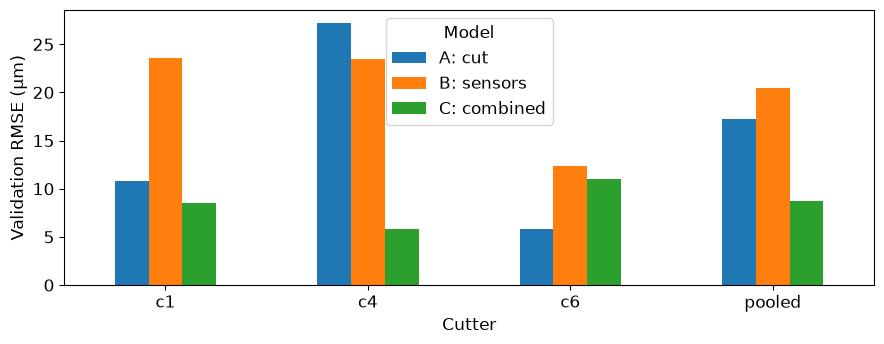

In [31]:
# PROVIDED: independently refit A/B/C, so E1–E3 answers are not prerequisites.
input_sets = [['cut_number'], sensor_columns, ['cut_number'] + sensor_columns]
model_names = ['A: cut', 'B: sensors', 'C: combined']
rows = []
# Keep each model's predictions in exactly the validation-table row order.
validation_predictions = []
fitted_models = []  # Preserve the training-only pipelines for the final overview.
for index in range(3):
    columns = input_sets[index]
    model = make_pipeline(StandardScaler(), LinearRegression())
    model.fit(train[columns], y_train)
    fitted_models.append(model)
    pred = model.predict(valid[columns])
    validation_predictions.append(pred.copy())
    rows.append([model_names[index], 'pooled', np.sqrt(mean_squared_error(y_valid, pred))])
    for cutter in ['c1', 'c4', 'c6']:
        mask = valid['cutter_id'].to_numpy() == cutter
        rows.append([model_names[index], cutter, np.sqrt(mean_squared_error(y_valid[mask], pred[mask]))])
comparison = pd.DataFrame(rows, columns=['Model', 'Cutter', 'RMSE_um'])
display(comparison.pivot(index='Model', columns='Cutter', values='RMSE_um').round(2))
comparison.pivot(index='Cutter', columns='Model', values='RMSE_um').plot.bar(rot=0)
plt.ylabel('Validation RMSE (µm)'); plt.tight_layout(); plt.show()

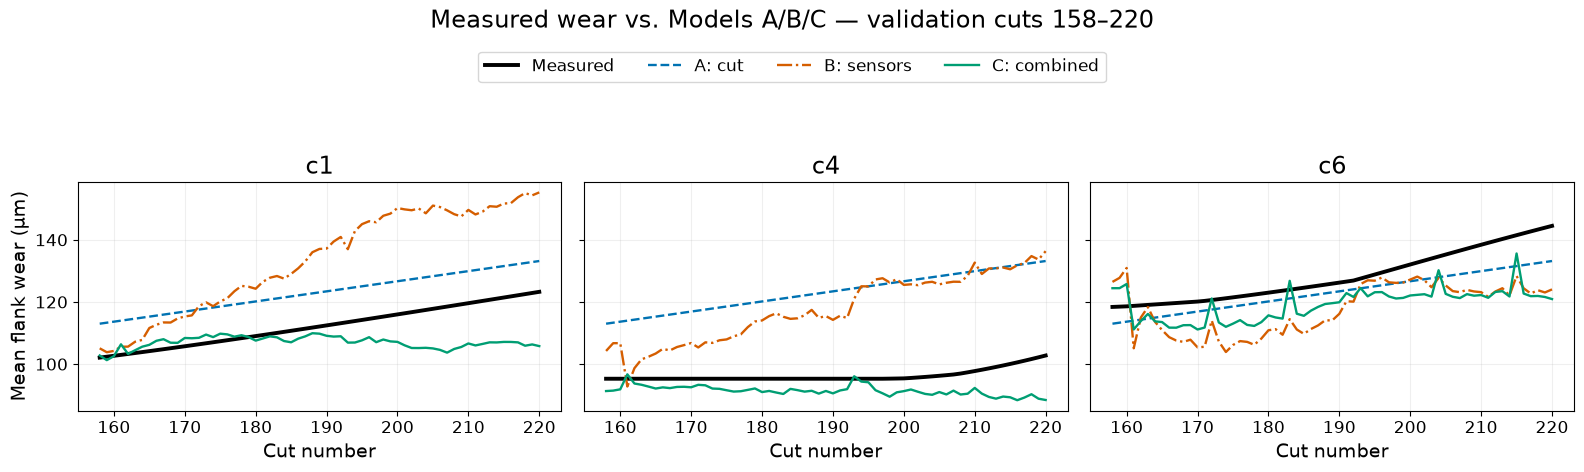

In [32]:
# PROVIDED: reuse the exact predictions scored above; no refitting here.
# Each panel shows one cutter. Identical colors and axis limits aid comparison.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
cutters = ['c1', 'c4', 'c6']
colors = ['#0072B2', '#D55E00', '#009E73']
styles = ['--', '-.', '-']
for panel in range(3):
    cutter = cutters[panel]
    mask = valid['cutter_id'].to_numpy() == cutter
    cut_numbers = valid.loc[mask, 'cut_number'].to_numpy()
    measured = valid.loc[mask, 'wear_mean_um'].to_numpy()
    ax = axes[panel]
    ax.plot(cut_numbers, measured, color='black', linewidth=2.8, label='Measured')
    for index in range(3):
        predicted = validation_predictions[index][mask]
        ax.plot(cut_numbers, predicted, color=colors[index], linestyle=styles[index],
                linewidth=1.7, label=model_names[index])
    ax.set_title(cutter, fontsize=17)
    ax.set_xlabel('Cut number', fontsize=14)
    ax.grid(alpha=.2)
axes[0].set_ylabel('Mean flank wear (µm)', fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(.5, .91), ncol=4, fontsize=12)
fig.suptitle('Measured wear vs. Models A/B/C — validation cuts 158–220', fontsize=17)
fig.tight_layout(rect=(0, 0, 1, .8))
plt.show()

**One possible response:** C has the lowest pooled validation RMSE (8.69 µm), compared with A (17.22) and B (20.48), but A wins on c6 (5.78 versus C 10.99 µm). I would provisionally choose C for this pooled objective if both cut history and sensors are available. A needs only cut history. This does not establish unseen-cutter performance or performance on the reserved last 30%.

### Optional — full trajectories, including training cuts (5–10 minutes)

Finish your E4 choice first. Reuse the three fixed models trained on cuts 1–157;
no refitting or new model selection occurs here. Backgrounds mark training
(1–157), validation (158–220), and later held-out cuts (221–315).
Training agreement is in-sample, not generalization evidence. The last block is
now revealed for a descriptive comparison: do not revise your choice after viewing
it or call it an untouched test in subsequent experiments. All three cutters were
represented in training. No whole-trajectory accuracy score is computed.

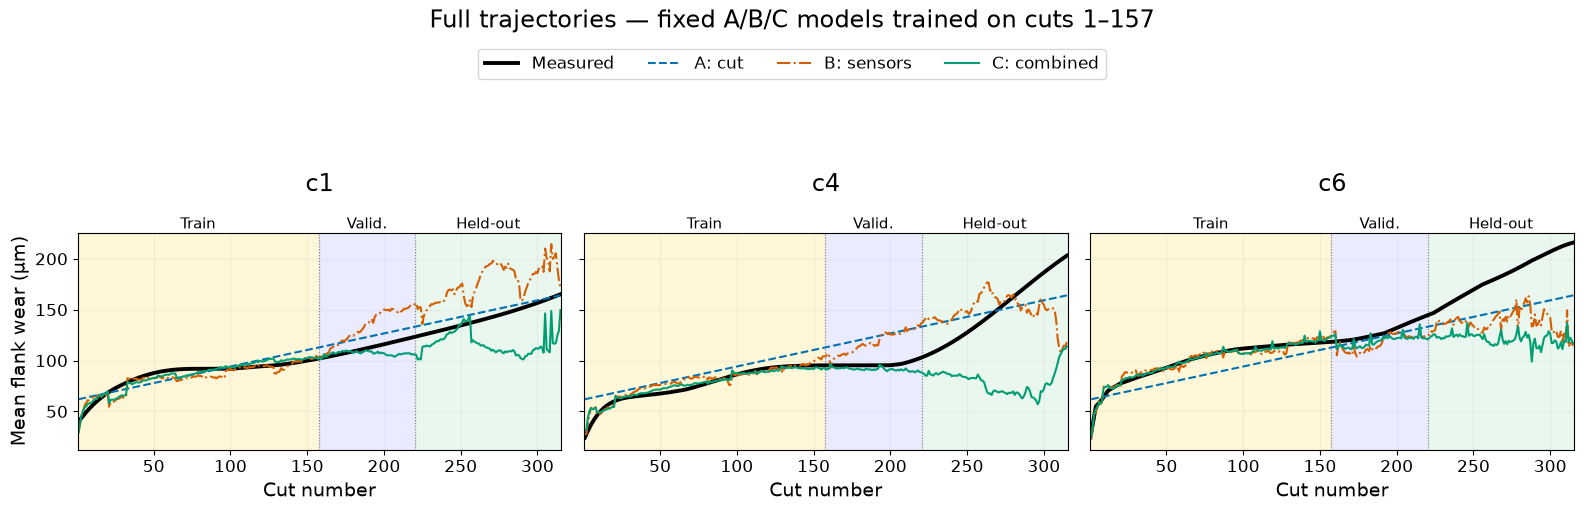

In [33]:
# PROVIDED: predict all 945 rows with the existing training-only pipelines.
full_predictions = []
for index in range(3):
    columns = input_sets[index]
    full_predictions.append(fitted_models[index].predict(data[columns]))

fig_full, axes_full = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)
for panel in range(3):
    cutter = cutters[panel]
    mask = data['cutter_id'].to_numpy() == cutter
    cut_numbers = data.loc[mask, 'cut_number'].to_numpy()
    measured = data.loc[mask, 'wear_mean_um'].to_numpy()
    ax = axes_full[panel]
    # Half-integer boundaries separate adjacent integer cut numbers exactly.
    ax.axvspan(.5, 157.5, color='#FFF0B3', alpha=.5)
    ax.axvspan(157.5, 220.5, color='#D9D9FF', alpha=.5)
    ax.axvspan(220.5, 315.5, color='#D6F0E0', alpha=.5)
    ax.axvline(157.5, color='gray', linewidth=.8, linestyle=':')
    ax.axvline(220.5, color='gray', linewidth=.8, linestyle=':')
    ax.plot(cut_numbers, measured, color='black', linewidth=2.8, label='Measured')
    for index in range(3):
        ax.plot(cut_numbers, full_predictions[index][mask], color=colors[index],
                linestyle=styles[index], linewidth=1.5, label=model_names[index])
    # x uses cut numbers; y uses axis fraction to keep labels above the data.
    ax.text(79, 1.02, 'Train', transform=ax.get_xaxis_transform(), ha='center', fontsize=11)
    ax.text(189, 1.02, 'Valid.', transform=ax.get_xaxis_transform(), ha='center', fontsize=11)
    ax.text(268, 1.02, 'Held-out', transform=ax.get_xaxis_transform(), ha='center', fontsize=11)
    ax.set_title(cutter, fontsize=17, pad=30)
    ax.set_xlim(.5, 315.5)
    ax.set_xlabel('Cut number', fontsize=14)
    ax.grid(alpha=.15)
axes_full[0].set_ylabel('Mean flank wear (µm)', fontsize=14)
handles, labels = axes_full[0].get_legend_handles_labels()
fig_full.legend(handles, labels, loc='upper center', bbox_to_anchor=(.5, .92), ncol=4, fontsize=12)
fig_full.suptitle('Full trajectories — fixed A/B/C models trained on cuts 1–157', fontsize=17)
fig_full.tight_layout(rect=(0, 0, 1, .78))
plt.show()

### Optional — same Model C inputs, Linear vs. Ridge (10–15 minutes)

Keep cut number + the 11 sensor features and the original training rows fixed.
Only regularization changes. Predict whether shrinking coefficients will help;
compare alpha = 0.1, 1, 10 using validation RMSE, then inspect the full curves.
Ridge is still a linear model. The target remains in µm.

This extension was added after inspecting the later-cut failures, so it is a
**follow-up diagnostic**, not a new untouched-test claim. Do not expand the alpha
list to chase later-cut results. Neither model is refitted on validation data.
Run Module E setup and E4 (comparison and validation plot) first. The optional
full-trajectory plot can be skipped; this extension adds no required code.

In [34]:
# PROVIDED: identical Model C inputs and training-only scaling for every candidate.
ridge_columns = ['cut_number'] + sensor_columns
ridge_alphas = [0.1, 1.0, 10.0]
ridge_candidates = []
ridge_rows = []
for ridge_alpha in ridge_alphas:
    ridge_candidate = make_pipeline(StandardScaler(), Ridge(alpha=ridge_alpha))
    ridge_candidate.fit(train[ridge_columns], y_train)
    ridge_valid = ridge_candidate.predict(valid[ridge_columns])
    ridge_rmse = np.sqrt(mean_squared_error(y_valid, ridge_valid))
    ridge_candidates.append(ridge_candidate)
    ridge_rows.append([ridge_alpha, ridge_rmse])
ridge_scores = pd.DataFrame(ridge_rows, columns=['alpha', 'Validation RMSE (µm)'])
display(ridge_scores.round(3))
# Choose only by validation RMSE; reuse that fitted pipeline without refitting.
ridge_best_index = int(ridge_scores['Validation RMSE (µm)'].idxmin())
ridge_selected = ridge_candidates[ridge_best_index]
print('Validation-selected alpha:', ridge_alphas[ridge_best_index])
ridge_full = ridge_selected.predict(data[ridge_columns])
# Reuse the fitted Linear pipeline directly: no optional-plot prerequisite.
linear_c_full = fitted_models[2].predict(data[ridge_columns])

# Report partitions separately: training fit is not evidence of generalization.
ridge_comparison_rows = []
partition_names = ['Training 1–157', 'Validation 158–220', 'Later 221–315 (diagnostic)']
partition_masks = [data['cut_number'].to_numpy() <= 157,
                   (data['cut_number'].to_numpy() >= 158) & (data['cut_number'].to_numpy() <= 220),
                   data['cut_number'].to_numpy() >= 221]
for partition_index in range(3):
    partition_mask = partition_masks[partition_index]
    observed = data.loc[partition_mask, 'wear_mean_um'].to_numpy()
    linear_error = np.sqrt(mean_squared_error(observed, linear_c_full[partition_mask]))
    ridge_error = np.sqrt(mean_squared_error(observed, ridge_full[partition_mask]))
    ridge_comparison_rows.append([partition_names[partition_index], linear_error, ridge_error])
ridge_comparison = pd.DataFrame(ridge_comparison_rows,
    columns=['Partition', 'Linear RMSE (µm)', 'Ridge RMSE (µm)'])
display(ridge_comparison.round(2))

,alpha,Validation RMSE (µm)
0,0.1,8.440
1,1.0,6.604
2,10.0,5.285


Validation-selected alpha: 10.0


,Partition,Linear RMSE (µm),Ridge RMSE (µm)
0,Training 1–157,3.99,4.81
1,Validation 158–220,8.69,5.29
2,Later 221–315 (diagnostic),61.63,32.45


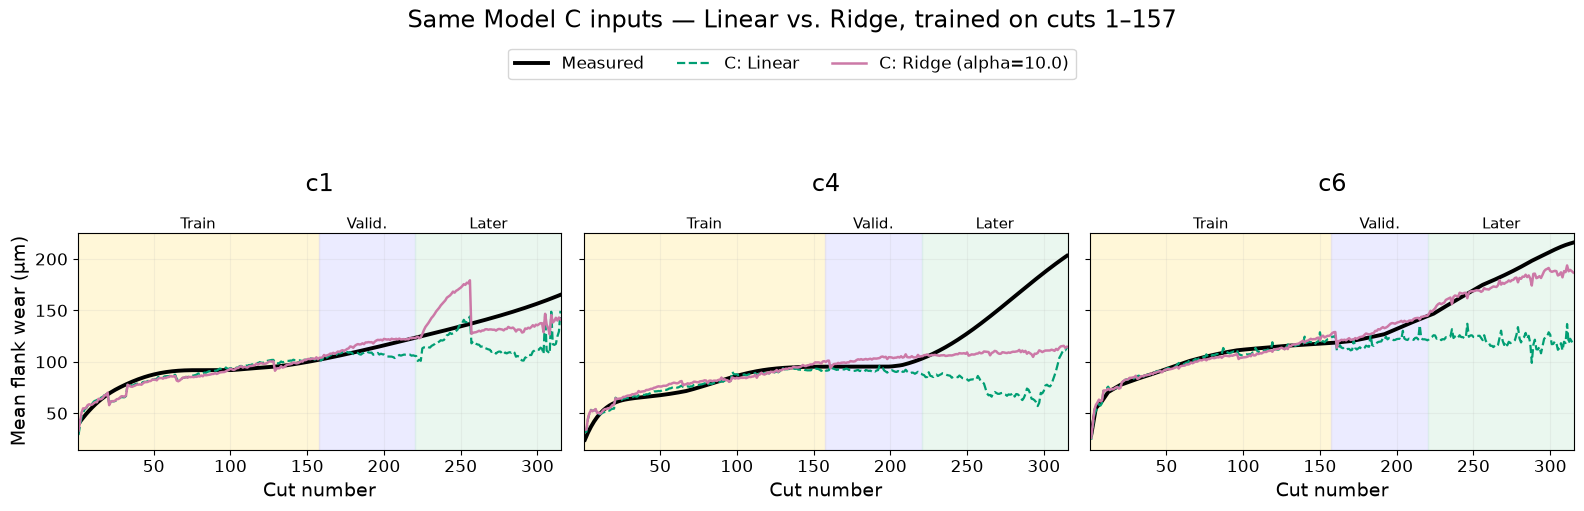

In [35]:
# PROVIDED: compare both predictions with measured wear for every cutter.
fig_ridge, axes_ridge = plt.subplots(1, 3, figsize=(16, 5.2), sharex=True, sharey=True)
for panel in range(3):
    cutter = cutters[panel]
    mask = data['cutter_id'].to_numpy() == cutter
    cut_numbers = data.loc[mask, 'cut_number'].to_numpy()
    ax = axes_ridge[panel]
    ax.axvspan(.5, 157.5, color='#FFF0B3', alpha=.5)
    ax.axvspan(157.5, 220.5, color='#D9D9FF', alpha=.5)
    ax.axvspan(220.5, 315.5, color='#D6F0E0', alpha=.5)
    ax.plot(cut_numbers, data.loc[mask, 'wear_mean_um'], color='black', linewidth=2.8, label='Measured')
    ax.plot(cut_numbers, linear_c_full[mask], color='#009E73', linestyle='--', linewidth=1.6, label='C: Linear')
    ax.plot(cut_numbers, ridge_full[mask], color='#CC79A7', linewidth=1.8,
            label='C: Ridge (alpha=' + str(ridge_alphas[ridge_best_index]) + ')')
    ax.text(79, 1.02, 'Train', transform=ax.get_xaxis_transform(), ha='center', fontsize=11)
    ax.text(189, 1.02, 'Valid.', transform=ax.get_xaxis_transform(), ha='center', fontsize=11)
    ax.text(268, 1.02, 'Later', transform=ax.get_xaxis_transform(), ha='center', fontsize=11)
    ax.set_title(cutter, fontsize=17, pad=30)
    ax.set_xlim(.5, 315.5)
    ax.set_xlabel('Cut number', fontsize=14)
    ax.grid(alpha=.15)
axes_ridge[0].set_ylabel('Mean flank wear (µm)', fontsize=14)
handles, labels = axes_ridge[0].get_legend_handles_labels()
fig_ridge.legend(handles, labels, loc='upper center', bbox_to_anchor=(.5, .92), ncol=3, fontsize=12)
fig_ridge.suptitle('Same Model C inputs — Linear vs. Ridge, trained on cuts 1–157', fontsize=17)
fig_ridge.tight_layout(rect=(0, 0, 1, .78))
plt.show()

**One possible observation:** Alpha 10 is selected. Pooled validation RMSE falls from 8.69 to 5.29 µm; later-cut RMSE falls from 61.63 to 32.45 µm. Regularization helps here, but later errors remain substantial. Check each cutter rather than assuming equal improvement. This is not evidence of performance on unseen cutters.

## Self-check

Can you explain a residual sign, distinguish training from validation, identify
which parameter you changed, and support a conclusion with a plot or metric?
Try a different condition before looking at the solution. Do not treat repeated
validation exploration as independent final testing.

References: [scikit-learn regression](https://scikit-learn.org/stable/supervised_learning.html),
[preprocessing](https://scikit-learn.org/stable/modules/preprocessing.html).
Synthetic formulas and noise are course-created demonstrations, not empirical
PHM laws. PHM provenance is linked in Module E.